# **CIS 5450 Final Project - Survival Strategies for Small Game Companies**
*name*

# Part 1: Introduction

The global video game industry has evolved into a highly competitive ecosystem, presenting both unprecedented opportunities and immense challenges for developers. This project conducts an in-depth analysis of the current gaming market utilizing the **Steam Games Dataset 2025**. To better understand the game market and provide strategies, we analyzed nearly 90,000 paid games out of over 263,000 games. Specifically, this research addresses a critical industry imbalance: the widening gap between major, well-established gaming corporations—which benefit from abundant resources, massive marketing budgets, and extensive brand visibility—and small or independent game developers.

By leveraging big data analytics, we aim to answer a pivotal research question: In today's highly competitive market, what data-driven strategies can small game companies adopt to survive, compete, and thrive? Our dataset mainly has 10 csv files:

`applications.csv`: all the games and their detail information

`categories.csv` & `application_categories.csv`: the categories of games

`genres.csv` & `application_genres.csv`: the types of the game

`developers.csv` & `application_developers.csv`: game developers

`publishers.csv` & `application_publishers.csv`: game publishers

`reviews.csv`: selected reviews from each game

These results and key takeaways are detailed below in our notebook. 

# Part 2: Data Loading & Wrangling

In this part, we load the Steam Games Dataset 2025 and apply data wrangling methods. Eventually we get a csv file contaning all the data we need in all stages of our research (EDA, hypothesis testing, modeling and analysis), so that we only need to import 1 csv file instead of 10 files in later tasks.

We first import all the packsges and libraries for the whole research.

In [69]:
# imports
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import re

from sklearn.linear_model import LassoCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb

## 2.1 Data Loading

Steam games Dataset 2025 is an open-source dataset on Kaggle, the link is below:

https://www.kaggle.com/datasets/abhishekgupta56447/steam-games-dataset-2025/data?select=steam_dataset_2025_csv

We download the dataset and save it in our working directory, then read all necessary files.


In [70]:
# set random state to make results reproducible
RANDOM_STATE = 42
DATA_DIR = r'/Users/pai/Desktop/steam_data_analysis/data/steam_dataset_2025_csv'
# load data
apps       = pd.read_csv(f'{DATA_DIR}/applications.csv', low_memory=False)
genres_ref = pd.read_csv(f'{DATA_DIR}/genres.csv')
app_genres = pd.read_csv(f'{DATA_DIR}/application_genres.csv')
cats_ref   = pd.read_csv(f'{DATA_DIR}/categories.csv')
app_cats   = pd.read_csv(f'{DATA_DIR}/application_categories.csv')
devs_ref   = pd.read_csv(f'{DATA_DIR}/developers.csv')
app_devs   = pd.read_csv(f'{DATA_DIR}/application_developers.csv')
pubs_ref   = pd.read_csv(f'{DATA_DIR}/publishers.csv')
app_pubs   = pd.read_csv(f'{DATA_DIR}/application_publishers.csv')
reviews    = pd.read_csv(f'{DATA_DIR}/reviews.csv')

## 2.2 Data Wrangling

### 2.2.1 Select Games and Process Columns

We start with `application.csv`, which is the largest file and contains various information about the games. We first need to select games that meet our requirements, and the requirements are as follows:

1. Select paid games.
2. Select "game", not "dlc" or others.
3. Select games pricing with USD.

Among 30 columns that this file provides, we discussed and kept necessary columns. We dropped columns that have unstructured data (words descriptions, links) and columns we believe will not influence the sales of the game. Columns we chose are listed below:

`'appid'`, `'name'`, `'release_date'`, `'required_age'`, `'supported_languages'`, `'mat_supports_windows'`, `'mat_supports_mac'`, `'mat_supports_linux'`, `'mat_initial_price'`, `'mat_achievement_count'` (convert to a binary variable indicating whether the game has a steam achievement system), `'recommendations_total'`


In [71]:
# filter out free games, non-game items, discounted games, non-USD games
apps_cleaned = apps.copy()
apps_cleaned = apps_cleaned[(apps_cleaned["is_free"]==False) & (apps_cleaned["mat_initial_price"]>0)]
apps_cleaned = apps_cleaned[apps_cleaned["type"]=="game"]
apps_cleaned = apps_cleaned[apps_cleaned["mat_currency"]=="USD"]

# filter the columns we need
apps_cleaned = (apps_cleaned[["appid", "name", "release_date", "required_age", 
    "supported_languages", "mat_supports_windows", "mat_supports_mac", "mat_supports_linux", 
    "mat_initial_price", "mat_achievement_count", "recommendations_total"]])
apps_cleaned.rename(columns={"mat_initial_price": "price_usd", 
    "mat_supports_windows": "supports_windows", "mat_supports_mac": "supports_mac", 
    "mat_supports_linux": "supports_linux"}, inplace=True)

apps_cleaned.head(5)

,appid,name,release_date,required_age,supported_languages,supports_windows,supports_mac,supports_linux,price_usd,mat_achievement_count,recommendations_total
0,10,Counter-Strike,2000-11-01,0,"English<strong>*</strong>, French<strong>*</st...",True,True,True,999.0,NaN,161854.0
1,20,Team Fortress Classic,1999-04-01,0,"English, French, German, Italian, Spanish - Sp...",True,True,True,499.0,NaN,6633.0
2,30,Day of Defeat,2003-05-01,0,"English, French, German, Italian, Spanish - Spain",True,True,True,499.0,NaN,4308.0
3,40,Deathmatch Classic,2001-06-01,0,"English, French, German, Italian, Spanish - Sp...",True,True,True,499.0,NaN,2338.0
4,50,Half-Life: Opposing Force,1999-11-01,0,"English, French, German, Korean",True,True,True,499.0,NaN,22793.0


After selecting the columns, we need to process them to make them suitable for further analysis. 

1. According to convention, divide the game prices stored in `'price_usd'` by 100 to get the price in USD; 
2. Split `'release_date'` into `'release_year'` and `'release_month'` to facilitate subsequent time-based market analysis; 
3. Process `'required_age'` by categorizing the data into two types: whether the player needs to be at least 18 years old to play the game; 
4. Count the number of different languages in `'supported_languages'` to serve as a basis for evaluating the game's localization level; 
5. Since `'mat_achievement_count'` contains a large number of NA values, we classify them as 1 or 0 based on whether they have values, to some extent judging the richness of game content based on the presence of an achievement system.

In [72]:
# divide the game prices stored in 'mat_initial_price' by 100 to get the price in USD
apps_cleaned["price_usd"] = apps_cleaned["price_usd"] / 100.0

# seperate the release_date column into release_year and release_month
apps_cleaned["release_date"] = pd.to_datetime(apps_cleaned["release_date"], errors='coerce')
apps_cleaned["release_year"] = apps_cleaned["release_date"].dt.year
apps_cleaned["release_month"] = apps_cleaned["release_date"].dt.month
apps_cleaned = apps_cleaned.dropna(subset=['release_year', 'release_month'])
apps_cleaned["release_year"]  = apps_cleaned["release_year"].astype(int)
apps_cleaned["release_month"] = apps_cleaned["release_month"].astype(int)

apps_cleaned.drop(columns=["release_date"], inplace=True)

# convert required_age to boolean: 0 = under 18 (all ages), 1 = 18+ (adult only)
apps_cleaned["required_age"] = pd.to_numeric(apps_cleaned["required_age"], errors='coerce').fillna(0)
apps_cleaned["required_age"] = (apps_cleaned["required_age"] >= 18).astype(int)

# parse supported_languages into a language count (int) using regular expression
def _count_languages(s):
    if pd.isna(s):
        return 1                              
    s = str(s).split('<br>')[0]              
    s = re.sub(r'<[^>]+>', '', s)            
    langs = [l.strip() for l in s.split(',') if l.strip()]
    return max(len(langs), 1)

apps_cleaned["supported_languages"] = apps_cleaned["supported_languages"].apply(_count_languages).astype(int)
apps_cleaned["supported_languages"].value_counts()

# convert mat_achievement_count to boolean "achievement_systems"
apps_cleaned.rename(columns={"mat_achievement_count": "achievement_systems"}, inplace=True)
apps_cleaned["achievement_systems"] = apps_cleaned["achievement_systems"].notna().astype(int)

apps_cleaned = apps_cleaned.reset_index(drop=True)

apps_cleaned.head(5)

,appid,name,required_age,supported_languages,supports_windows,supports_mac,supports_linux,price_usd,achievement_systems,recommendations_total,release_year,release_month
0,10,Counter-Strike,0,8,True,True,True,9.99,0,161854.0,2000,11
1,20,Team Fortress Classic,0,9,True,True,True,4.99,0,6633.0,1999,4
2,30,Day of Defeat,0,5,True,True,True,4.99,0,4308.0,2003,5
3,40,Deathmatch Classic,0,9,True,True,True,4.99,0,2338.0,2001,6
4,50,Half-Life: Opposing Force,0,4,True,True,True,4.99,0,22793.0,1999,11


### 2.2.2 Add Features: Categories

After processing the applications.csv in the previous step, we obtained a preliminary form that requires the addition of more features. For games, the category is a very important feature. In the `categories.csv`, there are a large number of categories, and in order to reduce the computations during the merge operation, we selected the 20 most frequently occurring categories.

In [73]:
# Filter out Categories
# Filter app_cats to games in apps_cleaned → app_cats_1
valid_appids = set(apps_cleaned["appid"])
total_games = len(valid_appids)
app_cats_1 = app_cats[app_cats["appid"].isin(valid_appids)].copy()

# Merge with cats_ref to attach category names
cats_ref_eng = cats_ref.rename(columns={"id": "category_id", "name": "category_name"})
app_cats_1 = app_cats_1.merge(cats_ref_eng, on="category_id", how="left")

# Count distinct games per category, sort descending → pick top 20
cat_game_count = (
    app_cats_1.groupby(["category_id", "category_name"])["appid"]
    .nunique()
    .reset_index()
    .rename(columns={"appid": "game_count"})
    .sort_values("game_count", ascending=False)
    .reset_index(drop=True)
)
cat_top20 = cat_game_count.head(20)

cat_top20

,category_id,category_name,game_count
0,130,Family Sharing,87537
1,142,Single-player,85689
2,68,Steam Achievements,45313
3,201,Steam Cloud,25011
4,75,Full controller support,20471
5,133,Multi-player,14214
6,307,Partial Controller Support,10998
7,85,Steam Trading Cards,10073
8,90,PvP,8434
9,160,Co-op,7921


However, is 20 a decent number? Do these categories cover most of the games we selected? We then computed the number of games that have at least 1 category in these 20 categories, and if these 20 categories cover over 90% of the games, we say it's appropriate. It turned out that these top 20 categories cover 99.2% of the selected games. 

In [74]:
# proving the top 20 categories cover over 90% of the games
# Build lookup: category_id -> set of appids
cat_to_games = (
    app_cats_1.groupby("category_id")["appid"]
    .apply(set)
    .to_dict()
)

# Compute unique games covered by top-20 categories (union, no double-counting)
covered = set()
for cid in cat_top20["category_id"]:
    covered |= cat_to_games.get(cid, set())
coverage_pct = len(covered) / total_games * 100

# Output 
print(f"Total games in apps_cleaned : {total_games:,}")
print(f"Games covered by top-20 cats: {len(covered):,}  ({coverage_pct:.1f}%)")

print(f"{'#':<4} {'Category Name':<42} {'Games':>8}  {'Individual%':>11}  {'Cumulative%':>12}")
print("─" * 82)
cum_covered = set()
for i, row in cat_top20.iterrows():
    cum_covered |= cat_to_games.get(row["category_id"], set())
    print(f"{i+1:<4} {row['category_name']:<42} {row['game_count']:>8,}  "
          f"{row['game_count']/total_games*100:>10.1f}%  "
          f"{len(cum_covered)/total_games*100:>11.1f}%")

top20_cat_names = cat_top20["category_name"].tolist()   
print(f"\nTop-20 category names:\n{top20_cat_names}")

Total games in apps_cleaned : 88,917
Games covered by top-20 cats: 88,167  (99.2%)
#    Category Name                                 Games  Individual%   Cumulative%
──────────────────────────────────────────────────────────────────────────────────
1    Family Sharing                               87,537        98.4%         98.4%
2    Single-player                                85,689        96.4%         98.8%
3    Steam Achievements                           45,313        51.0%         98.9%
4    Steam Cloud                                  25,011        28.1%         98.9%
5    Full controller support                      20,471        23.0%         98.9%
6    Multi-player                                 14,214        16.0%         99.0%
7    Partial Controller Support                   10,998        12.4%         99.0%
8    Steam Trading Cards                          10,073        11.3%         99.0%
9    PvP                                           8,434         9.5%         

### 2.2.3 Add Features: Genres

Game genres can also be used to judge whether a game will have good sales, so we need to include the genres feature. We have also selected the 20 most frequently occurring genres.

In [75]:
# Filter out Genres
app_genres_1 = app_genres[app_genres["appid"].isin(valid_appids)].copy()

# Merge with genres_ref to attach genre names
genres_ref_eng = genres_ref.rename(columns={"id": "genre_id", "name": "genre_name"})
app_genres_1 = app_genres_1.merge(genres_ref_eng, on="genre_id", how="left")

# Count distinct games per genre, sort descending → pick top 20
genre_game_count = (
    app_genres_1.groupby(["genre_id", "genre_name"])["appid"]
    .nunique()
    .reset_index()
    .rename(columns={"appid": "game_count"})
    .sort_values("game_count", ascending=False)
    .reset_index(drop=True)
)
genre_top20 = genre_game_count.head(20)

genre_top20

,genre_id,genre_name,game_count
0,31,Indie,63613
1,32,Casual,39372
2,122,Action,36166
3,113,Adventure,35883
4,11,Simulation,19058
5,5,Strategy,17603
6,144,RPG,16219
7,107,Early Access,8615
8,62,Sports,3922
9,15,Racing,3294


We conducted the same proving method, and we found that these 20 genres cover 99.8% of our selected games.

In [76]:
# proving the top 20 genres cover over 90% of the games
# Build lookup: genre_id -> set of appids
genre_to_games = (
    app_genres_1.groupby("genre_id")["appid"]
    .apply(set)
    .to_dict()
)

# Compute unique games covered by top-20 genres (union, no double-counting)
covered = set()
for gid in genre_top20["genre_id"]:
    covered |= genre_to_games.get(gid, set())
coverage_pct = len(covered) / total_games * 100

# ── Output ────────────────────────────────────────────────────────────────────
print(f"Total games in apps_cleaned   : {total_games:,}")
print(f"Games covered by top-20 genres: {len(covered):,}  ({coverage_pct:.1f}%)")
print(f"Threshold (90%)               : {int(total_games * 0.9):,}")
print(f"Passes 90% threshold          : {'YES ✓' if coverage_pct >= 90 else 'NO ✗'}\n")

print(f"{'#':<4} {'Genre Name':<42} {'Games':>8}  {'Individual%':>11}  {'Cumulative%':>12}")
print("─" * 82)
cum_covered = set()
for i, row in genre_top20.iterrows():
    cum_covered |= genre_to_games.get(row["genre_id"], set())
    print(f"{i+1:<4} {row['genre_name']:<42} {row['game_count']:>8,}  "
          f"{row['game_count']/total_games*100:>10.1f}%  "
          f"{len(cum_covered)/total_games*100:>11.1f}%")

top20_genre_names = genre_top20["genre_name"].tolist()
print(f"\nTop-20 genre names:\n{top20_genre_names}")


Total games in apps_cleaned   : 88,917
Games covered by top-20 genres: 88,769  (99.8%)
Threshold (90%)               : 80,025
Passes 90% threshold          : YES ✓

#    Genre Name                                    Games  Individual%   Cumulative%
──────────────────────────────────────────────────────────────────────────────────
1    Indie                                        63,613        71.5%         71.5%
2    Casual                                       39,372        44.3%         81.8%
3    Action                                       36,166        40.7%         89.3%
4    Adventure                                    35,883        40.4%         92.7%
5    Simulation                                   19,058        21.4%         95.3%
6    Strategy                                     17,603        19.8%         97.1%
7    RPG                                          16,219        18.2%         98.3%
8    Early Access                                  8,615         9.7%         98

### 2.2.4 Add Features: Developers & Publishers

The next step is to include the developers of the game as a feature. The developers of the game are the basis for us to determine whether the game comes from a big company or a small one. This is very important for our hypothesis testing and the core issues we need to address. For this feature, we first extract the selected game's developer, then calculate the number of games developed by these developers in the `application_developers.csv` file, using this value as the feature. For games with multiple developers, we select the first developer as the main one.

The publisher of the game is also a feature we need to process. The decision of choosing different publishers or whether to self-publish can affect the game's sales, thus influencing the sales revenue. For the publisher, we adopt the same approach as with the developer, calculating the number of games published by different publishers to serve as the feature.

In [77]:
# ── Developer & Publisher features ───────────────────────────────────────────
# dev_game_count / pub_game_count: count from ALL games
devs_ref_m = devs_ref.rename(columns={"id": "developer_id", "name": "developer_name"})
pubs_ref_m = pubs_ref.rename(columns={"id": "publisher_id", "name": "publisher_name"})

dev_counts_all = (
    app_devs.groupby("developer_id")["appid"]
    .nunique().reset_index()
    .rename(columns={"appid": "dev_game_count"})
)
pub_counts_all = (
    app_pubs.groupby("publisher_id")["appid"]
    .nunique().reset_index()
    .rename(columns={"appid": "pub_game_count"})
)

# Filter to apps_cleaned, attach names + all-games counts
app_devs_1 = (
    app_devs[app_devs["appid"].isin(valid_appids)].copy()
    .merge(devs_ref_m, on="developer_id", how="left")
    .merge(dev_counts_all, on="developer_id", how="left")
)
app_pubs_1 = (
    app_pubs[app_pubs["appid"].isin(valid_appids)].copy()
    .merge(pubs_ref_m, on="publisher_id", how="left")
    .merge(pub_counts_all, on="publisher_id", how="left")
)

# Primary dev/pub per game (sort by id → take first)
primary_dev = (
    app_devs_1.sort_values("developer_id")
    .groupby("appid", as_index=False).first()
    [["appid", "developer_name", "dev_game_count"]]
)
primary_pub = (
    app_pubs_1.sort_values("publisher_id")
    .groupby("appid", as_index=False).first()
    [["appid", "publisher_name", "pub_game_count"]]
)

print(primary_dev.head(5))
print(primary_pub.head(5))

   appid    developer_name  dev_game_count
0     10             Valve              56
1     20             Valve              56
2     30             Valve              56
3     40             Valve              56
4     50  Gearbox Software             121
   appid publisher_name  pub_game_count
0     10          Valve              50
1     20          Valve              50
2     30          Valve              50
3     40          Valve              50
4     50          Valve              50


We add a boolean feature to record whether the game is self-published, i.e., to determine if the game's developers and publishers have intersections.

In [78]:
# is_self_published: 1 if any dev name ∩ any pub name for that game
dev_name_sets = app_devs_1.groupby("appid")["developer_name"].apply(set)
pub_name_sets  = app_pubs_1.groupby("appid")["publisher_name"].apply(set)
name_cmp = dev_name_sets.to_frame().join(pub_name_sets, how="outer")
name_cmp["is_self_published"] = name_cmp.apply(
    lambda r: int(bool(
        (r["developer_name"] if isinstance(r["developer_name"], set) else set()) &
        (r["publisher_name"]  if isinstance(r["publisher_name"],  set) else set())
    )), axis=1
)
is_self_pub = name_cmp[["is_self_published"]].reset_index()

is_self_pub.head(5)

,appid,is_self_published
0,10,1
1,20,1
2,30,1
3,40,1
4,50,0


### 2.2.5 Add Features: Estimated Sales & Revenue

Estimated sales is the most important part, as all subsequent analyses rely on this feature. However, game sales on Steam are considered private data and are not publicly available, so we cannot directly obtain the sales figures from the Steam Games Dataset 2025.

Nevertheless, we still have a solution. We found in the `applications.csv` file that each game has a column named `'recommendations_total'`, which records the total number of positive reviews for each game. Since Steam requires purchasing the game to leave a review, we can use this data to indirectly estimate the game's sales. Considering that there are negative reviews and most buyers do not leave reviews, we multiply this value by a coefficient (30) to estimate the sales.

We noticed that many games have `'recommendations_total'` as null values, because Steam hides the number of positive reviews for games with very few. For these games, our solution is: using the `reviews.csv` file, we calculate the number of reviews and use a linear calculation formula to estimate sales (this formula also takes into account the case where the number of reviews is zero).

Finally, we can get the revenue by multiplying the game's price by the estimated sales.

Keytakeaways: 

1. Calculate sales according to recommendation_totals: Sales = recommendation_totals * 30.
2. For those have 0 in recommendation_totals: Sales = reviews_count * Boxleiter Multiplier (10) + 100
3. Revenue = Sales * Price

In [79]:
# ── Calculate estimated sales ────────────────────────────────────────────────
# recommendations_total * 30  (if > 0)
# review_count * 10 + 100   (if recommendations_total == 0 or NaN)
# revenue = sales * price

# Prepare reviews table: count per game for apps_cleaned only
reviews_slim = reviews[["recommendationid", "appid"]]
review_counts = (
    reviews_slim[reviews_slim["appid"].isin(valid_appids)]
    .groupby("appid")["recommendationid"]
    .count()
    .reset_index()
    .rename(columns={"recommendationid": "review_count"})
)

# Normalise recommendations_total to numeric
apps_cleaned["recommendations_total"] = pd.to_numeric(
    apps_cleaned["recommendations_total"], errors="coerce"
).fillna(0)

# merge reviews_count to main_df
main_df = apps_cleaned.copy()
main_df = main_df.merge(review_counts, on="appid", how="left")
main_df["review_count"] = main_df["review_count"].fillna(0).astype(int)

# calculate estimated sales and revenue
has_reco = main_df["recommendations_total"] > 0
main_df["estimated_sales"] = 0
main_df.loc[has_reco,  "estimated_sales"] = (main_df.loc[has_reco,  "recommendations_total"] * 30).astype(int)
main_df.loc[~has_reco, "estimated_sales"] = (main_df.loc[~has_reco, "review_count"] * 10 + 100).astype(int)
main_df["revenue"] = (main_df["price_usd"] * main_df["estimated_sales"]).round(2)

main_df.head(5)

,appid,name,required_age,supported_languages,supports_windows,supports_mac,supports_linux,price_usd,achievement_systems,recommendations_total,release_year,release_month,review_count,estimated_sales,revenue
0,10,Counter-Strike,0,8,True,True,True,9.99,0,161854.0,2000,11,0,4855620,48507643.8
1,20,Team Fortress Classic,0,9,True,True,True,4.99,0,6633.0,1999,4,0,198990,992960.1
2,30,Day of Defeat,0,5,True,True,True,4.99,0,4308.0,2003,5,0,129240,644907.6
3,40,Deathmatch Classic,0,9,True,True,True,4.99,0,2338.0,2001,6,0,70140,349998.6
4,50,Half-Life: Opposing Force,0,4,True,True,True,4.99,0,22793.0,1999,11,0,683790,3412112.1


### 2.2.6 Combine Features

After completing the above feature engineering, we will merge all the features into our `‘main_df.csv’`. This file contains all the data needed for our subsequent analysis. For categories and genres, we use one-hot encoding (OHE). We also add a feature `'is_small_company'`. We consider companies that develop a small number of games, as well as those that develop a large number of games but at very low prices, to be small companies. We perform the final organization work on `main_df`.

In [80]:
# Category OHE (top-20) 
def _clean_col(prefix, name):
    return prefix + re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")

top20_cat_ids = set(cat_top20["category_id"])
cat_ohe = app_cats_1[app_cats_1["category_id"].isin(top20_cat_ids)].copy()
cat_ohe["col"] = cat_ohe["category_name"].apply(lambda n: _clean_col("cat_", n))
cat_pivot = (
    cat_ohe.assign(val=1)
    .pivot_table(index="appid", columns="col", values="val", aggfunc="max", fill_value=0)
    .reset_index()
)

# Genre OHE (top-20) 
top20_genre_ids = set(genre_top20["genre_id"])
genre_ohe = app_genres_1[app_genres_1["genre_id"].isin(top20_genre_ids)].copy()
genre_ohe["col"] = genre_ohe["genre_name"].apply(lambda n: _clean_col("genre_", n))
genre_pivot = (
    genre_ohe.assign(val=1)
    .pivot_table(index="appid", columns="col", values="val", aggfunc="max", fill_value=0)
    .reset_index()
)

# organize main_df 
main_df = main_df.merge(primary_dev,                              on="appid", how="left")
main_df = main_df.merge(primary_pub[["appid","publisher_name","pub_game_count"]], on="appid", how="left")
main_df = main_df.merge(is_self_pub,                             on="appid", how="left")
main_df = main_df.merge(cat_pivot,                               on="appid", how="left")
main_df = main_df.merge(genre_pivot,                             on="appid", how="left")

# Fill missing
for col in ["dev_game_count", "pub_game_count", "is_self_published"]:
    main_df[col] = main_df[col].fillna(0).astype(int)
cat_cols   = [c for c in main_df.columns if c.startswith("cat_")]
genre_cols = [c for c in main_df.columns if c.startswith("genre_")]
main_df[cat_cols + genre_cols] = main_df[cat_cols + genre_cols].fillna(0).astype(int)

# company scale: small company if the developer has made <= 5 games
main_df["is_small_company"] = 0
main_df.loc[main_df["dev_game_count"] <= 5, "is_small_company"] = 1
main_df.loc[(main_df["dev_game_count"] > 20) & (main_df["price_usd"] <= 5), "is_small_company"] = 1

# Summary 
main_df.drop(columns=["recommendations_total", "review_count"], inplace=True)
main_df = main_df.sort_values(by="revenue", ascending=False)
main_df = main_df.reset_index(drop=True)


Save main_df to our working directory

In [81]:
main_df.head(10)

,appid,name,required_age,supported_languages,supports_windows,supports_mac,supports_linux,price_usd,achievement_systems,release_year,...,genre_massively_multiplayer,genre_racing,genre_rpg,genre_simulation,genre_sports,genre_strategy,genre_utilities,genre_video_production,genre_violent,is_small_company
0,2358720,Black Myth: Wukong,0,14,True,True,True,59.99,1,2024,...,0,0,1,0,0,0,0,0,0,1
1,1091500,Cyberpunk 2077,0,19,True,True,True,59.99,1,2020,...,0,0,1,0,0,0,0,0,0,0
2,1245620,ELDEN RING,0,15,True,True,True,59.99,1,2022,...,0,0,1,0,0,0,0,0,0,0
3,252490,Rust,0,25,True,True,True,39.99,1,2018,...,1,0,1,0,0,0,0,0,0,0
4,1086940,Baldur's Gate 3,0,15,True,True,True,59.99,1,2023,...,0,0,1,0,0,1,0,0,0,0
5,292030,The Witcher 3: Wild Hunt,0,17,True,True,True,39.99,1,2015,...,0,0,1,0,0,0,0,0,0,0
6,553850,HELLDIVERS™ 2,0,14,True,True,True,39.99,1,2024,...,0,0,0,0,0,0,0,0,0,0
7,221100,DayZ,0,12,True,True,True,49.99,1,2018,...,1,0,0,0,0,0,0,0,0,0
8,275850,No Man's Sky,0,14,True,True,True,59.99,1,2016,...,0,0,0,0,0,0,0,0,0,0
9,374320,DARK SOULS™ III,0,12,True,True,True,59.99,1,2016,...,0,0,0,0,0,0,0,0,0,0


In [82]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88917 entries, 0 to 88916
Data columns (total 59 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   appid                           88917 non-null  int64  
 1   name                            88917 non-null  object 
 2   required_age                    88917 non-null  int64  
 3   supported_languages             88917 non-null  int64  
 4   supports_windows                88917 non-null  bool   
 5   supports_mac                    88917 non-null  bool   
 6   supports_linux                  88917 non-null  bool   
 7   price_usd                       88917 non-null  float64
 8   achievement_systems             88917 non-null  int64  
 9   release_year                    88917 non-null  int64  
 10  release_month                   88917 non-null  int64  
 11  estimated_sales                 88917 non-null  int64  
 12  revenue                         

In [83]:
main_df.to_csv("main_df.csv", index=False)

# Part 3: EDA

eda主要是对市场状况的分析，进行的分析在后面有用是最好的，比如画图发现revenue不平衡，后面分析的时候取对数这种。
这部分的内容明天汇报要

# Part 4: Feature Selection

Since the goal of our project is to provide actionable, interpretable strategies for small game companies, we prioritize feature selection methods that preserve the original meaning of each feature, rather than dimensionality-reduction techniques like PCA which create abstract components.

We apply a three-step feature selection pipeline:

1. **Near-zero-variance filtering:** Remove features where a single value dominates >= 98% of the data, as they carry almost no discriminative information.
2. **Correlation-based filtering:** Visualize the feature correlation heatmap and remove one feature from each highly correlated pair (|r| > 0.85) to reduce multicollinearity, keeping the one more correlated with the target.
3. **Lasso (L1 regularization):** Use `LassoCV` with cross-validation to shrink feature coefficients. Features with |coefficient| < 0.01 are dropped as negligible contributors, yielding a sparse, interpretable feature set.

**Target variable:** `revenue` is log-transformed via `log1p` to handle extreme right-skewness.

**Excluded columns:** `appid`, `name`, `developer_name`, `publisher_name` (identifiers/text), and `estimated_sales` (data leakage since `revenue = price * estimated_sales`).

## 4.1 Near-zero-variance

We first prepare the feature matrix `X` and the target variable `y`. Identifier columns and `estimated_sales` are excluded to prevent data leakage. Boolean columns are cast to integers.

For the near-zero-variance step, rather than only removing features with exactly zero variance, we compute the **dominant value ratio** — the proportion of the most frequent value in each column. If a single value accounts for >= 98% of all observations, the feature provides almost no discriminative power and is dropped. For example, `supports_windows` is True for nearly all games and would be removed by this filter.

In [84]:
# ── Step 0: Prepare features and target ────────────────────────────────────────
# Exclude identifiers, text columns, and estimated_sales (data leakage)
exclude_cols = {"appid", "name", "developer_name", "publisher_name",
                "estimated_sales", "revenue"}
feature_cols = [c for c in main_df.columns if c not in exclude_cols]

X = main_df[feature_cols].copy()
# Convert boolean columns (supports_windows/mac/linux) to int for consistency
for col in X.select_dtypes(include="bool").columns:
    X[col] = X[col].astype(int)

# Log-transform revenue to handle extreme right-skewness
y = np.log1p(main_df["revenue"])

print(f"Initial feature count: {X.shape[1]}")

# ── Step 1: Near-zero-variance filtering ──────────────────────────────────────
# If >= 98% of values are the same, the feature has almost no discriminative power
DOMINANCE_THRESHOLD = 0.98

low_var_cols = []
for col in X.columns:
    # Compute the proportion of the most frequent value
    top_freq = X[col].value_counts(normalize=True).iloc[0]
    if top_freq >= DOMINANCE_THRESHOLD:
        low_var_cols.append((col, top_freq))

if low_var_cols:
    drop_names = [c for c, _ in low_var_cols]
    print(f"\nRemoved {len(low_var_cols)} near-zero-variance features "
          f"(most-frequent value >= {DOMINANCE_THRESHOLD:.0%}):")
    for col, freq in low_var_cols:
        print(f"  {col:<40} dominant value ratio: {freq:.2%}")
    X = X.drop(columns=drop_names)
else:
    print("\nNo near-zero-variance features found.")

print(f"Features after near-zero-variance filtering: {X.shape[1]}")

Initial feature count: 53

Removed 15 near-zero-variance features (most-frequent value >= 98%):
  required_age                             dominant value ratio: 99.85%
  supports_windows                         dominant value ratio: 100.00%
  supports_mac                             dominant value ratio: 99.80%
  supports_linux                           dominant value ratio: 99.78%
  cat_family_sharing                       dominant value ratio: 98.45%
  genre_animation_modeling                 dominant value ratio: 99.65%
  genre_audio_production                   dominant value ratio: 99.82%
  genre_design_illustration                dominant value ratio: 99.52%
  genre_education                          dominant value ratio: 99.68%
  genre_game_development                   dominant value ratio: 99.76%
  genre_gore                               dominant value ratio: 99.75%
  genre_massively_multiplayer              dominant value ratio: 98.79%
  genre_utilities                      

## 4.2 Correlation-based Filtering

Multicollinearity — when features are highly correlated with each other — inflates the variance of regression coefficients and makes them unreliable for interpretation. To address this, we compute the Pearson correlation matrix and identify all feature pairs with |r| > 0.85.

For each highly correlated pair, we keep the feature that has a **stronger correlation with the target** (log-revenue) and drop the other. This ensures we retain the most predictive feature from each redundant pair.

We visualize the correlation heatmap both **before and after filtering** to confirm that the remaining features no longer exhibit severe collinearity.

Highly correlated pairs (|r| > 0.85):

  achievement_systems <-> cat_steam_achievements: r=0.860  | corr(y): 0.207 vs 0.216 -> drop 'achievement_systems'
  cat_tracked_controller_support <-> cat_vr_only: r=0.858  | corr(y): 0.004 vs 0.015 -> drop 'cat_tracked_controller_support'

Dropped 2 features: ['achievement_systems', 'cat_tracked_controller_support']
Features after correlation filtering: 36


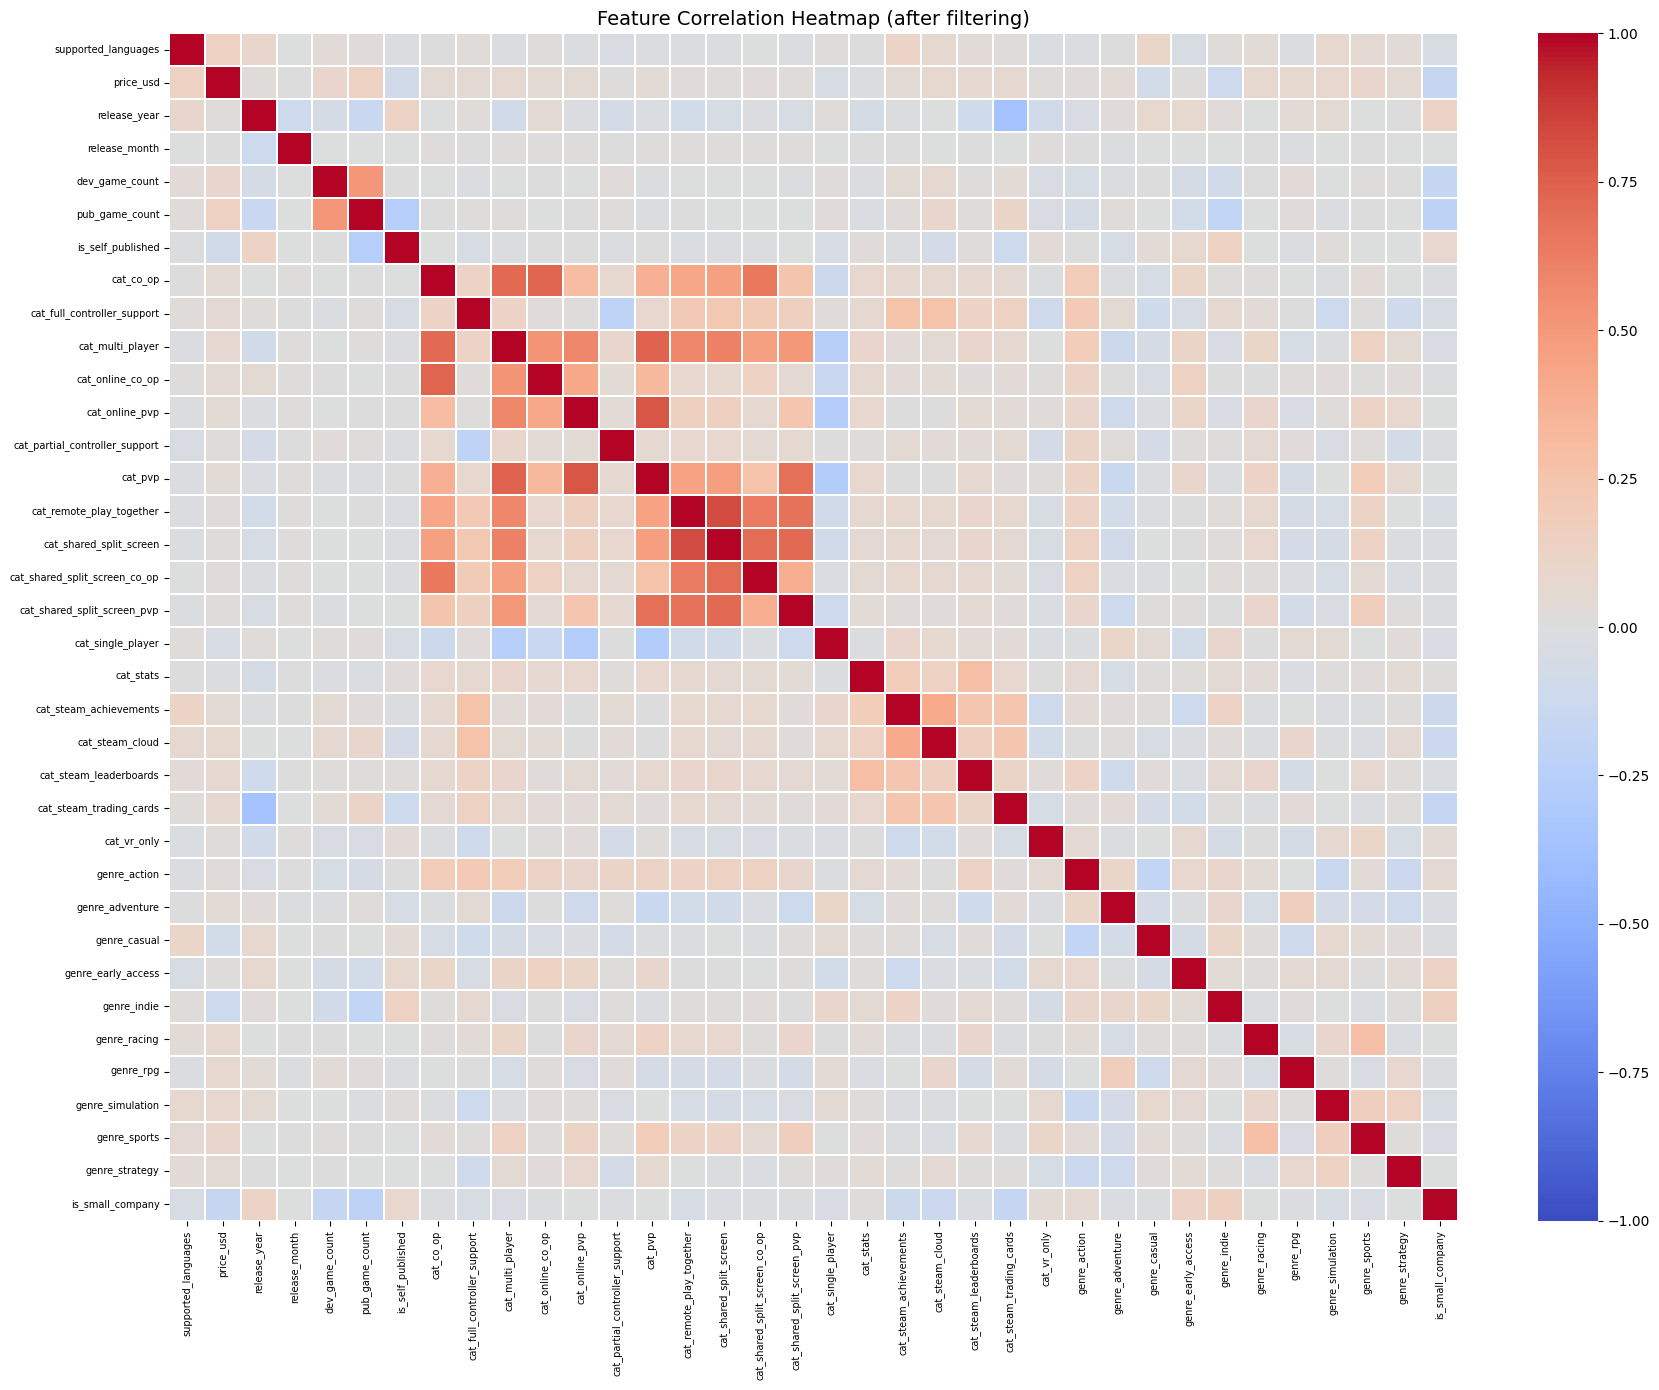

In [85]:
# ── Step 2: Correlation-based filtering ────────────────────────────────────────
corr_matrix = X.corr()

# Extract the upper triangle to avoid duplicate pairs
CORR_THRESHOLD = 0.85
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        val = upper_tri.loc[idx, col]
        if pd.notna(val) and abs(val) > CORR_THRESHOLD:
            high_corr_pairs.append((idx, col, val))

# For each pair, drop the feature less correlated with y (log-revenue)
to_drop = set()
if high_corr_pairs:
    print(f"Highly correlated pairs (|r| > {CORR_THRESHOLD}):\n")
    for f1, f2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        corr_f1_y = X[f1].corr(y)
        corr_f2_y = X[f2].corr(y)
        drop = f2 if abs(corr_f1_y) >= abs(corr_f2_y) else f1
        to_drop.add(drop)
        print(f"  {f1} <-> {f2}: r={r:.3f}  "
              f"| corr(y): {abs(corr_f1_y):.3f} vs {abs(corr_f2_y):.3f} "
              f"-> drop '{drop}'")

    X = X.drop(columns=list(to_drop))
    print(f"\nDropped {len(to_drop)} features: {sorted(to_drop)}")
else:
    print("No highly correlated features found.")

print(f"Features after correlation filtering: {X.shape[1]}")

# ── Heatmap after filtering ───────────────────────────────────────────────────
corr_after = X.corr()

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr_after, annot=False, cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            xticklabels=True, yticklabels=True)
ax.set_title("Feature Correlation Heatmap (after filtering)", fontsize=14)
ax.tick_params(axis='both', labelsize=7)
plt.tight_layout()
plt.show()

## 4.3 LASSO Filtering

Lasso (Least Absolute Shrinkage and Selection Operator) is a linear regression method that adds an **L1 penalty** to the loss function:

$$\min_{\beta} \frac{1}{2n} \|y - X\beta\|_2^2 + \alpha \|\beta\|_1$$

The key property of the L1 penalty ($\|\beta\|_1 = \sum|\beta_j|$) is that it drives some coefficients to **exactly zero**, effectively performing automatic feature selection. The regularization strength $\alpha$ controls how aggressively features are eliminated: a larger $\alpha$ produces a sparser model with fewer features.

We use `LassoCV` which performs **5-fold cross-validation** over a grid of 100 $\alpha$ values to find the optimal regularization strength. After fitting, we apply an additional threshold: features with |coefficient| < 0.01 are treated as negligible and dropped.

All features are **standardized** (zero mean, unit variance) before fitting Lasso, so the resulting coefficients are directly comparable in magnitude — a larger absolute coefficient means a stronger effect on log-revenue.

Optimal alpha: 0.000100
Lasso R² score: 0.4376

Coefficient threshold: 0.01
Features selected by Lasso: 33 / 36
Features dropped (|coef| < 0.01): 3
Dropped: [('supported_languages', np.float64(0.0007)), ('cat_co_op', np.float64(0.004)), ('cat_single_player', np.float64(-0.0021))]


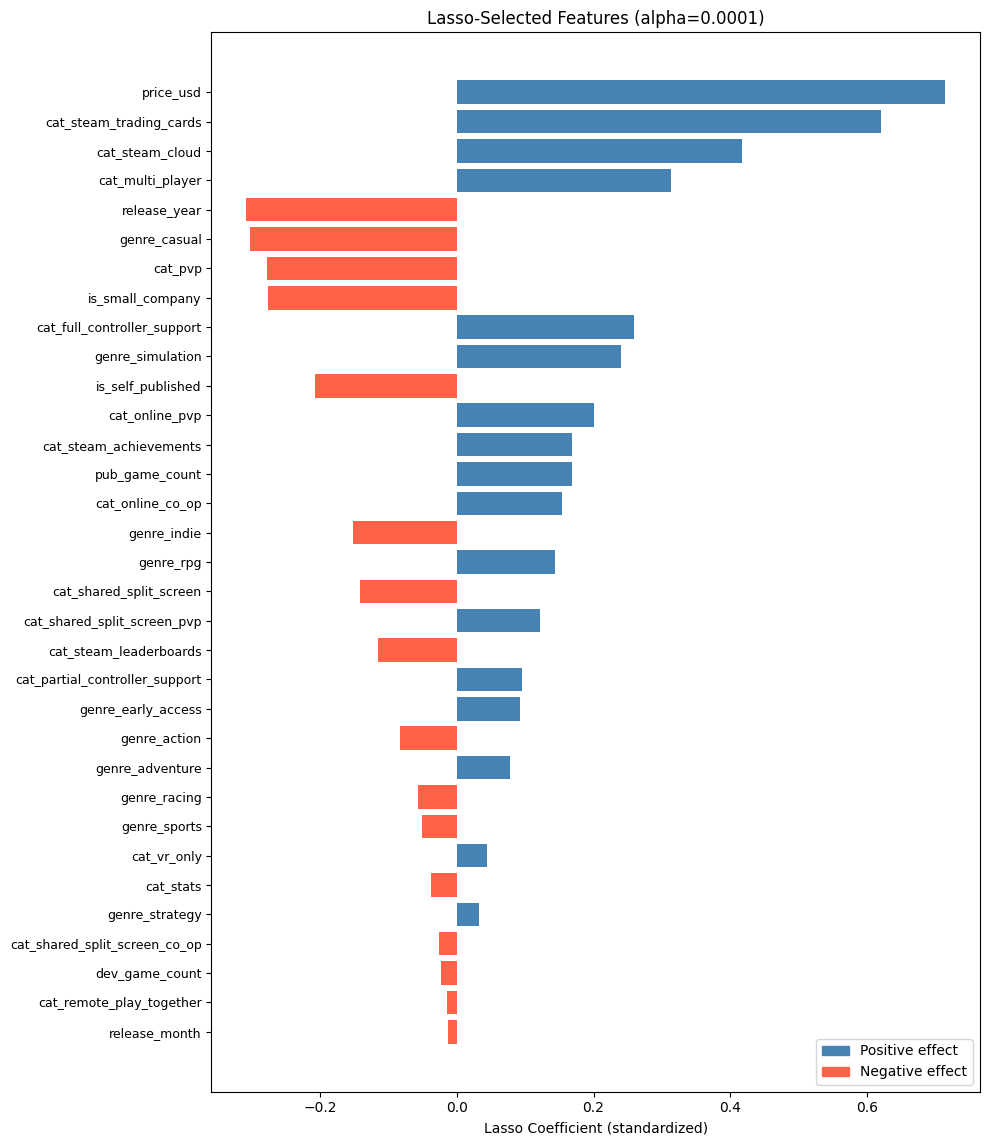

In [86]:
# ── Step 3: Lasso feature selection ───────────────────────────────────────────
# Standardize so Lasso coefficients are comparable across features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5-fold CV over 100 alpha values to find optimal regularization strength
lasso_cv = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5,
                   random_state=RANDOM_STATE, max_iter=10000)
lasso_cv.fit(X_scaled, y)

print(f"Optimal alpha: {lasso_cv.alpha_:.6f}")
print(f"Lasso R² score: {lasso_cv.score(X_scaled, y):.4f}")

# Extract coefficients and apply threshold
lasso_coefs = pd.Series(lasso_cv.coef_, index=X.columns)

# Drop features whose |coef| is below this threshold (negligible contribution)
COEF_THRESHOLD = 0.01
selected_mask = lasso_coefs.abs() >= COEF_THRESHOLD
selected = lasso_coefs[selected_mask].sort_values(key=abs, ascending=False)
dropped  = lasso_coefs[~selected_mask]

print(f"\nCoefficient threshold: {COEF_THRESHOLD}")
print(f"Features selected by Lasso: {len(selected)} / {len(X.columns)}")
print(f"Features dropped (|coef| < {COEF_THRESHOLD}): {len(dropped)}")
if len(dropped) > 0:
    print(f"Dropped: {list(zip(dropped.index, dropped.round(4).values))}")

# Visualize: blue = positive effect on revenue, red = negative effect
fig, ax = plt.subplots(figsize=(10, max(6, len(selected) * 0.35)))
colors = ["steelblue" if c > 0 else "tomato" for c in selected.values]
ax.barh(range(len(selected)), selected.values, color=colors)
ax.set_yticks(range(len(selected)))
ax.set_yticklabels(selected.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Lasso Coefficient (standardized)")
ax.set_title(f"Lasso-Selected Features (alpha={lasso_cv.alpha_:.4f})")
blue_patch = mpatches.Patch(color='steelblue', label='Positive effect')
red_patch  = mpatches.Patch(color='tomato',    label='Negative effect')
ax.legend(handles=[blue_patch, red_patch], loc='lower right')
plt.tight_layout()
plt.show()

In [87]:
# ── Final selected features ───────────────────────────────────────────────────
selected_features = selected.index.tolist()

X_selected = main_df[selected_features].copy()
for col in X_selected.select_dtypes(include="bool").columns:
    X_selected[col] = X_selected[col].astype(int)

print(f"Feature selection summary:")
print(f"  Initial features:              52")
print(f"  After near-zero-var filtering: {52 - len(low_var_cols)}")
print(f"  After correlation filtering:   {52 - len(low_var_cols) - len(to_drop)}")
print(f"  After Lasso selection:         {len(selected_features)}")
print(f"\nFinal {len(selected_features)} features for modeling:")
for i, f in enumerate(selected_features):
    print(f"  {i+1:>2}. {f:<40} (coef: {selected[f]:+.4f})")

print(f"\nX_selected shape: {X_selected.shape}")
print(f"y shape:          {y.shape}")

Feature selection summary:
  Initial features:              52
  After near-zero-var filtering: 37
  After correlation filtering:   35
  After Lasso selection:         33

Final 33 features for modeling:
   1. price_usd                                (coef: +0.7146)
   2. cat_steam_trading_cards                  (coef: +0.6206)
   3. cat_steam_cloud                          (coef: +0.4170)
   4. cat_multi_player                         (coef: +0.3139)
   5. release_year                             (coef: -0.3082)
   6. genre_casual                             (coef: -0.3027)
   7. cat_pvp                                  (coef: -0.2775)
   8. is_small_company                         (coef: -0.2772)
   9. cat_full_controller_support              (coef: +0.2593)
  10. genre_simulation                         (coef: +0.2406)
  11. is_self_published                        (coef: -0.2072)
  12. cat_online_pvp                           (coef: +0.2005)
  13. cat_steam_achievements            

**Key Takeaways from Feature Selection:**

1. **Near-zero-variance filtering** removed features where a single value dominates >= 98% of observations (e.g., `supports_windows` is True for almost all games), as they provide negligible discriminative power.
2. **Correlation-based filtering** identified and removed redundant features with |r| > 0.85. For each correlated pair, we kept the one with stronger correlation to the target variable (log-revenue), ensuring minimal information loss.
3. **Lasso regularization** further narrowed the feature set by shrinking negligible coefficients (|coef| < 0.01) to zero. The resulting Lasso coefficient chart directly reveals the direction and relative strength of each feature's effect on revenue.
4. Through the three-step pipeline, the feature count was reduced from the original 52 to a compact, interpretable subset — ready for modeling with minimal multicollinearity and no redundant features.
5. `X_selected` and `y` (log-transformed revenue) are prepared as the final inputs for the modeling stage.

# Part 5: Hypothesis Test

这一部分进行假设检验：光环效应？自发行更好？价格高利润多？

# Part 6: Modeling

这一步分进行建模，先用线性模型，RF，xgboost等建立一个模型的baseline（这几个里面好的那个）然后baseline的基础上进行调参 gridsearch等

考虑问题：建模是用全部游戏还是小游戏公司的游戏

我新加了一个feature，‘is_small_company’来记录是否是小公司的游戏，有这个之后可以训完模型加上SHAP进行解释分析

# Part 7: Conclusion

结论，我们给小游戏公司提的建议，结合shap分析（ai说的）

# Part 8: Challenges

# Part 9: Future Direction